In [1]:
import pandas as pd
import numpy as np

In [2]:
from datasets import load_dataset

print("Loading tweets...")
df_tweets_raw = pd.read_csv("twitter_training.csv")
df_tweets_raw = df_tweets_raw.dropna()
df_tweets_raw.columns = ["id", "subject", "sentiment", "text"]
print(f"  Tweets raw: {len(df_tweets_raw)}")

print("Loading IMDB...")
df_imdb_raw = pd.read_csv("IMDB Dataset.csv")
print(f"  IMDB raw: {len(df_imdb_raw)}")

print("Loading Yelp...")
yelp_ds = load_dataset("Yelp/yelp_review_full", split="train")
df_yelp_raw = yelp_ds.to_pandas()
print(f"  Yelp raw: {len(df_yelp_raw)}")

print("Loading Amazon...")
df_amazon_raw = pd.read_csv("Reviews.csv")
df_amazon_raw = df_amazon_raw.dropna(subset=["Text", "Score"])
print(f"  Amazon raw: {len(df_amazon_raw)}")

print("\nAll datasets loaded.")

Loading tweets...
  Tweets raw: 73995
Loading IMDB...
  IMDB raw: 50000
Loading Yelp...


  Yelp raw: 650000
Loading Amazon...
  Amazon raw: 568454

All datasets loaded.


In [3]:
tweets = df_tweets_raw[["text", "sentiment"]].copy()
tweets["sentiment"] = tweets["sentiment"].str.lower()
tweets = tweets[tweets["sentiment"].isin(["positive", "negative", "neutral"])].copy()
tweets["source"] = "tweets"
print(f"Tweets: {len(tweets)}")
print(tweets["sentiment"].value_counts().to_dict())

imdb = df_imdb_raw.rename(columns={"review": "text"})[["text", "sentiment"]].copy()
imdb["sentiment"] = imdb["sentiment"].str.lower()
imdb["source"] = "imdb"
print(f"\nIMDB: {len(imdb)}")
print(imdb["sentiment"].value_counts().to_dict())

yelp = df_yelp_raw[df_yelp_raw["label"].isin([0, 2, 4])].copy()
yelp["sentiment"] = yelp["label"].map({0: "negative", 2: "neutral", 4: "positive"})
yelp = yelp[["text", "sentiment"]].copy()
yelp["source"] = "yelp"
print(f"\nYelp: {len(yelp)}")
print(yelp["sentiment"].value_counts().to_dict())

amazon = df_amazon_raw[df_amazon_raw["Score"].isin([1, 3, 5])].copy()
amazon["sentiment"] = amazon["Score"].map({1: "negative", 3: "neutral", 5: "positive"})
amazon = amazon.rename(columns={"Text": "text"})[["text", "sentiment"]].copy()
amazon["source"] = "amazon"
print(f"\nAmazon: {len(amazon)}")
print(amazon["sentiment"].value_counts().to_dict())

Tweets: 61120
{'negative': 22358, 'positive': 20654, 'neutral': 18108}

IMDB: 50000
{'positive': 25000, 'negative': 25000}

Yelp: 390000
{'positive': 130000, 'negative': 130000, 'neutral': 130000}

Amazon: 458030
{'positive': 363122, 'negative': 52268, 'neutral': 42640}


In [4]:
combined = pd.concat([tweets, imdb, yelp, amazon], ignore_index=True)
combined["text_length"] = combined["text"].str.len()

combined["bucket"] = pd.cut(
    combined["text_length"],
    bins=[0, 80, 280, 800, np.inf],
    labels=["super_short", "short", "medium", "long"],
    right=True,
)

print(f"Combined: {len(combined)} samples")
print(f"Length range: {combined['text_length'].min()} - {combined['text_length'].max()}")

print("\n--- Available samples per bucket x source ---")
print(combined.groupby(["bucket", "source"]).size().unstack(fill_value=0))

print("\n--- Available samples per bucket x source x sentiment ---")
print(combined.groupby(["bucket", "source", "sentiment"]).size().to_frame("count").reset_index())

Combined: 959150 samples
Length range: 1 - 21409

--- Available samples per bucket x source ---
source       amazon   imdb  tweets    yelp
bucket                                    
super_short    3019     13   27357   12229
short        217428   1274   31667   87972
medium       186669  16982    2095  168510
long          50914  31731       1  121289

--- Available samples per bucket x source x sentiment ---
         bucket  source sentiment   count
0   super_short  amazon  negative     255
1   super_short  amazon   neutral     193
2   super_short  amazon  positive    2571
3   super_short    imdb  negative      10
4   super_short    imdb  positive       3
5   super_short  tweets  negative    9928
6   super_short  tweets   neutral    6418
7   super_short  tweets  positive   11011
8   super_short    yelp  negative    3199
9   super_short    yelp   neutral    3463
10  super_short    yelp  positive    5567
11        short  amazon  negative   20942
12        short  amazon   neutral   15418

In [5]:
bucket_config = {
    "super_short": {"target": 20000, "ratios": {"tweets": 0.40, "yelp": 0.20, "amazon": 0.20, "imdb": 0.20}},
    "short":       {"target": 20000, "ratios": {"tweets": 0.40, "yelp": 0.20, "amazon": 0.20, "imdb": 0.20}},
    "medium":      {"target": 10000, "ratios": {"tweets": 0.25, "yelp": 0.25, "amazon": 0.25, "imdb": 0.25}},
    "long":        {"target": 10000, "ratios": {"tweets": 0.00, "yelp": 0.40, "amazon": 0.40, "imdb": 0.20}},
}

def sample_source(df, n, random_state=42):
    if len(df) == 0 or n <= 0:
        return df.iloc[:0]
    if len(df) <= n:
        return df
    sentiments = df["sentiment"].unique()
    per_sent = n // len(sentiments)
    idx = []
    for sv in sentiments:
        g = df[df["sentiment"] == sv]
        idx.extend(g.sample(n=min(len(g), per_sent), random_state=random_state).index.tolist())
    return df.loc[idx]

buckets = {}
for bucket_name, cfg in bucket_config.items():
    target = cfg["target"]
    ratios = cfg["ratios"]
    bucket_pool = combined[combined["bucket"] == bucket_name].copy()

    source_targets = {src: int(target * ratio) for src, ratio in ratios.items()}
    sampled = {}
    shortfall = 0

    for src, src_target in source_targets.items():
        pool = bucket_pool[bucket_pool["source"] == src]
        sampled[src] = sample_source(pool, src_target)
        shortfall += src_target - len(sampled[src])

    if shortfall > 0:
        for src in ratios:
            if shortfall <= 0:
                break
            pool = bucket_pool[bucket_pool["source"] == src]
            already_used = sampled[src].index.tolist()
            remaining_pool = pool.drop(index=already_used, errors="ignore")
            extra = sample_source(remaining_pool, shortfall)
            if len(extra) > 0:
                sampled[src] = pd.concat([sampled[src], extra])
                shortfall -= len(extra)

    bucket_df = pd.concat(sampled.values(), ignore_index=True)
    buckets[bucket_name] = bucket_df

    print(f"\n{bucket_name}: {len(bucket_df)} samples")
    print(f"  source:    {bucket_df['source'].value_counts().to_dict()}")
    print(f"  sentiment: {bucket_df['sentiment'].value_counts().to_dict()}")


super_short: 20000 samples
  source:    {'tweets': 12969, 'yelp': 3999, 'amazon': 3019, 'imdb': 13}
  sentiment: {'positive': 8230, 'negative': 5921, 'neutral': 5849}

short: 20000 samples
  source:    {'tweets': 10728, 'yelp': 3999, 'amazon': 3999, 'imdb': 1274}
  sentiment: {'positive': 6955, 'negative': 6803, 'neutral': 6242}

medium: 10000 samples
  source:    {'yelp': 2904, 'imdb': 2502, 'amazon': 2499, 'tweets': 2095}
  sentiment: {'negative': 3861, 'positive': 3643, 'neutral': 2496}

long: 9999 samples
  source:    {'yelp': 3999, 'amazon': 3999, 'imdb': 2000, 'tweets': 1}
  sentiment: {'negative': 3666, 'positive': 3666, 'neutral': 2667}


In [6]:
final_df = pd.concat(buckets.values(), ignore_index=True)

print(f"=== Final Dataset: {len(final_df)} samples ===")
print()
print("--- By bucket ---")
print(final_df["bucket"].value_counts().sort_index())
print()
print("--- By sentiment ---")
print(final_df["sentiment"].value_counts())
print()
print("--- By source ---")
print(final_df["source"].value_counts())
print()
print("--- Source x Bucket ---")
print(final_df.groupby(["bucket", "source"]).size().unstack(fill_value=0))

=== Final Dataset: 59999 samples ===

--- By bucket ---
bucket
super_short    20000
short          20000
medium         10000
long            9999
Name: count, dtype: int64

--- By sentiment ---
sentiment
positive    22494
negative    20251
neutral     17254
Name: count, dtype: int64

--- By source ---
source
tweets    25793
yelp      14901
amazon    13516
imdb       5789
Name: count, dtype: int64

--- Source x Bucket ---
source       amazon  imdb  tweets  yelp
bucket                                 
super_short    3019    13   12969  3999
short          3999  1274   10728  3999
medium         2499  2502    2095  2904
long           3999  2000       1  3999


In [7]:
from sklearn.model_selection import train_test_split

final_df["strat_key"] = final_df["sentiment"] + "_" + final_df["bucket"].astype(str)

train_df, temp_df = train_test_split(
    final_df, test_size=0.30, random_state=42, stratify=final_df["strat_key"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=2/3, random_state=42, stratify=temp_df["strat_key"]
)

for d in [train_df, val_df, test_df, final_df]:
    d.drop(columns="strat_key", inplace=True)

print(f"Train: {len(train_df)}  ({len(train_df)/len(final_df)*100:.1f}%)")
print(f"Val:   {len(val_df)}  ({len(val_df)/len(final_df)*100:.1f}%)")
print(f"Test:  {len(test_df)}  ({len(test_df)/len(final_df)*100:.1f}%)")

test_super_short = test_df[test_df["bucket"] == "super_short"].reset_index(drop=True)
test_short       = test_df[test_df["bucket"] == "short"].reset_index(drop=True)
test_medium      = test_df[test_df["bucket"] == "medium"].reset_index(drop=True)
test_long        = test_df[test_df["bucket"] == "long"].reset_index(drop=True)

print("\n--- Test sub-sets by length ---")
for name, tdf in [("test_super_short", test_super_short), ("test_short", test_short),
                   ("test_medium", test_medium), ("test_long", test_long)]:
    print(f"\n  {name}: {len(tdf)} samples")
    print(f"    sentiment: {tdf['sentiment'].value_counts().to_dict()}")
    print(f"    source:    {tdf['source'].value_counts().to_dict()}")

Train: 41999  (70.0%)
Val:   6000  (10.0%)
Test:  12000  (20.0%)

--- Test sub-sets by length ---

  test_super_short: 4000 samples
    sentiment: {'positive': 1646, 'negative': 1184, 'neutral': 1170}
    source:    {'tweets': 2625, 'yelp': 756, 'amazon': 615, 'imdb': 4}

  test_short: 4001 samples
    sentiment: {'positive': 1391, 'negative': 1361, 'neutral': 1249}
    source:    {'tweets': 2117, 'amazon': 846, 'yelp': 758, 'imdb': 280}

  test_medium: 2000 samples
    sentiment: {'negative': 772, 'positive': 729, 'neutral': 499}
    source:    {'yelp': 560, 'imdb': 519, 'amazon': 490, 'tweets': 431}

  test_long: 1999 samples
    sentiment: {'negative': 733, 'positive': 733, 'neutral': 533}
    source:    {'yelp': 811, 'amazon': 775, 'imdb': 412, 'tweets': 1}


--- Text Length Distribution ---
count    59999.000000
mean       397.168919
std        604.392115
min          1.000000
25%         70.000000
50%        161.000000
75%        448.000000
max      12930.000000
Name: text_length, dtype: float64

bucket
super_short    20000
short          20000
medium         10000
long            9999
Name: count, dtype: int64


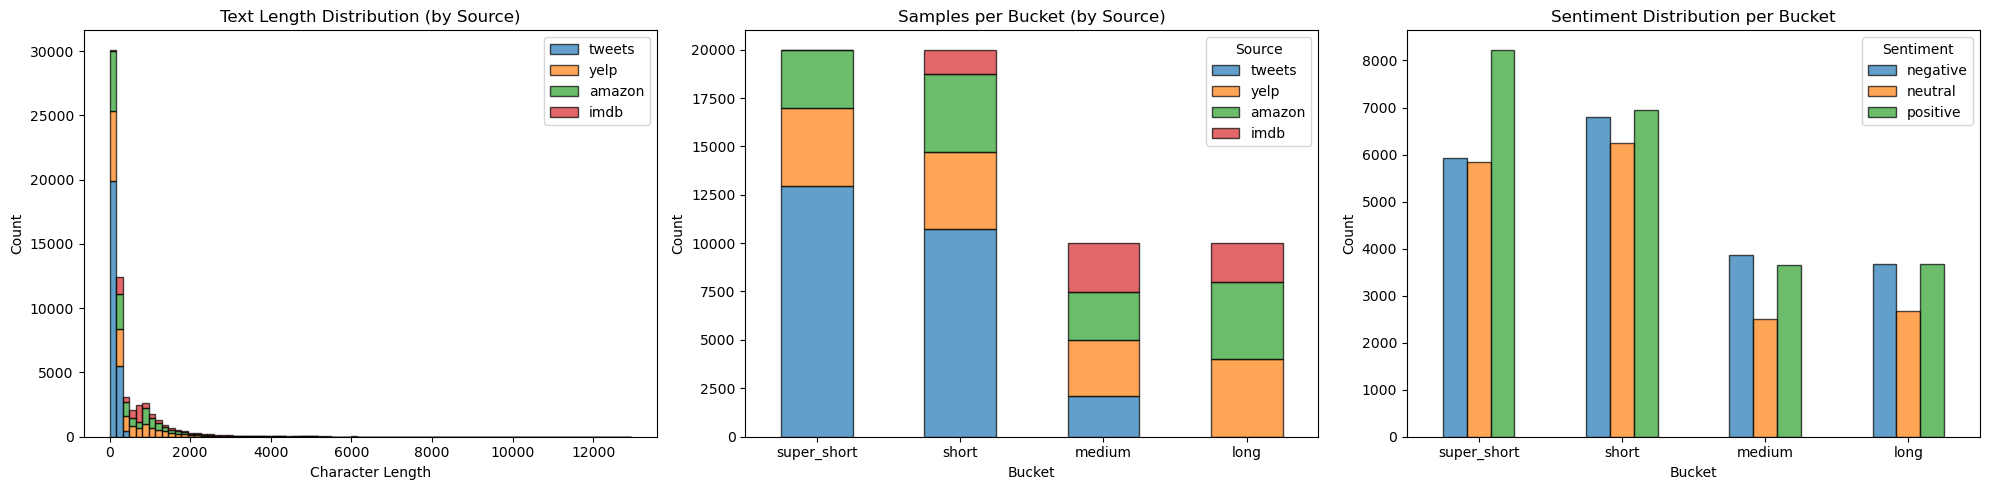

In [8]:
import matplotlib.pyplot as plt

print("--- Text Length Distribution ---")
print(final_df["text_length"].describe())
print()
print(final_df["bucket"].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sources = ["tweets", "yelp", "amazon", "imdb"]
lengths_by_source = [final_df[final_df["source"] == s]["text_length"] for s in sources]
axes[0].hist(lengths_by_source, bins=80, stacked=True,
             label=sources, edgecolor="black", alpha=0.7)
axes[0].set_title("Text Length Distribution (by Source)")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Count")
axes[0].legend()

bucket_source = final_df.groupby(["bucket", "source"]).size().unstack(fill_value=0)
bucket_source = bucket_source.reindex(columns=sources, fill_value=0)
bucket_source.plot(kind="bar", stacked=True, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("Samples per Bucket (by Source)")
axes[1].set_xlabel("Bucket")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Source")

sentiments = ["negative", "neutral", "positive"]
bucket_sent = final_df.groupby(["bucket", "sentiment"]).size().unstack(fill_value=0)
bucket_sent = bucket_sent.reindex(columns=sentiments, fill_value=0)
bucket_sent.plot(kind="bar", ax=axes[2], edgecolor="black", alpha=0.7)
axes[2].set_title("Sentiment Distribution per Bucket")
axes[2].set_xlabel("Bucket")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [9]:
final_df.to_csv("final_dataset.csv", index=False)
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)
test_super_short.to_csv("test_super_short.csv", index=False)
test_short.to_csv("test_short.csv", index=False)
test_medium.to_csv("test_medium.csv", index=False)
test_long.to_csv("test_long.csv", index=False)

print("Exported CSVs:")
for name in ["final_dataset", "train_dataset", "val_dataset", "test_dataset",
             "test_super_short", "test_short", "test_medium", "test_long"]:
    print(f"  {name}.csv")

print("\n--- 20 Random Samples ---")
final_df.sample(100, random_state=42)

Exported CSVs:
  final_dataset.csv
  train_dataset.csv
  val_dataset.csv
  test_dataset.csv
  test_super_short.csv
  test_short.csv
  test_medium.csv
  test_long.csv

--- 20 Random Samples ---


,text,sentiment,source,text_length,bucket
12628,We,neutral,tweets,2,super_short
51841,What do you want out of your Vegas experience?...,positive,yelp,1472,long
47430,Well i bought this because it was all Whole Fo...,neutral,amazon,650,medium
8525,Thank you Amazon.,positive,tweets,17,super_short
8279,the perfect,positive,tweets,11,super_short
...,...,...,...,...,...
20091,Johnson & Johnson Clean & clear cleanser an...,positive,tweets,142,short
35852,THIS WAS A GREAT GIFT TO MYSELF THE COFFEE IS ...,positive,amazon,137,short
24418,@OregonChai did finally stop making the sugar ...,neutral,tweets,166,short
20518,Tomorrow is Wordless Day at the LHS. The aim i...,positive,tweets,276,short


In [10]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

final_df.sample(100, random_state=42)

,text,sentiment,source,text_length,bucket
12628,We,neutral,tweets,2,super_short
51841,"What do you want out of your Vegas experience? That's what it comes down to when booking at The Signature. Do you want noisy, party hardy, loud, smoking neighbors and atmosphere? Go somewhere else. It's off the strip, so it's quiet, calm and everything the strip is not.\n\nThe rooms are very clean and quite large...stocked kitchenette, separate sitting area, giant bathroom. We booked through Luxury Suites International (LSI) so I knew we'd be on a low floor with no view and not all the resort amenties but they tell you that...and it's $79! If I wanted all the amenties, I'd pay the extra $100 and book through The Signature. You have to walk about 5-7 minutes to get to the strip but for me, no problem. I liked that trade for the quiet when I wanted to sleep. Never even heard a neighbor. The restaurant had a good, if pricey breakfast/lunch menu and we weren't disappointed by the food or service there. The front desk, concierge and valets were helpful, polite and speedy.\n\nThere are a lot of complaints about the walk to the strip and the location at the end of the strip. All I have to say about that is do some research, people. Look at a map, read the website. Those points are obvious. \n\nIf you want a clean, large, nicely appointed room that's inexpensive and you don't mind a short walk...try The Signature. If you want to be right on the strip or in the middle of it or if you'd like your entire trip to be a party...go somewhere else.",positive,yelp,1472,long
47430,"Well i bought this because it was all Whole Foods had that was organic and I wanted a dark dutch process, I don't use it for baking I make cocoa from scratch so thats all i use it for. My cocoa had absolutely no chocolate taste, it was incredibly bland. The next day i made Hershy's cocoa from scratch and found it to be much more chocolatey than this which isn't saying much as many people seem to think Hersheys isn't that hot. Perhaps the flavor is more pronounced in bake goods, but i do like that it is not treated with chemicals as I too get migraines, but I don't think that's what gives people the migraines is the actual chocolate chemicals.",neutral,amazon,650,medium
8525,Thank you Amazon.,positive,tweets,17,super_short
8279,the perfect,positive,tweets,11,super_short
15759,Just OK - The food is pretty good but it is somewhat over priced in my opinion.,neutral,yelp,79,super_short
16861,"great for late night open 24/7, I am in!",neutral,yelp,40,super_short
15125,"After the change of ownership, this place is horrible now. It's just too salty!",negative,yelp,80,super_short
9366,I'X m really digging off this new gold insignia!,positive,tweets,48,super_short
26030,"At the same time, despite the fact that there are currently some 100 million people living below the poverty line, most of them do not have access to health services and do not have access to health care, while most of them do not have access to health care.",negative,tweets,258,short
